In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
os.getcwd()
file = '../Scenario_Analysis_NEWEST.xlsx'
df = pd.read_excel(file, sheet_name='CO2Storage')
df = df.set_index(df.columns[0])
df = df.T
hours = df.index.str.replace("T","").astype(int)
start_date = pd.Timestamp("2019-01-01 00:00")
dt_index = start_date + pd.to_timedelta(hours-1, unit="h")
df.index = dt_index
df.index.name = "datetime"
df.index.freq = 'h'




In [2]:
months = {data.index[0].strftime("%B"): data 
          for _, data in df.groupby(df.index.month)}
months['August']

Unnamed: 0,Baseline,H2,BioFixed,CO2Trans,SpotPrice
datetime,,,,,
2019-08-01 00:00:00,12.000000,12.000000,1.102625,12.000000,50.47
2019-08-01 01:00:00,12.000000,12.000000,1.470167,12.000000,50.84
2019-08-01 02:00:00,12.000000,12.000000,1.837708,12.000000,50.66
2019-08-01 03:00:00,12.000000,12.000000,2.205250,12.000000,50.77
2019-08-01 04:00:00,12.000000,12.000000,2.572792,12.000000,50.94
...,...,...,...,...,...
2019-08-31 19:00:00,9.511242,9.447492,1.632458,9.261502,60.40
2019-08-31 20:00:00,8.324583,8.260834,0.000000,8.324583,54.82
2019-08-31 21:00:00,8.324583,8.260834,0.000000,8.324583,50.47


In [3]:
#representative week
month_df = months['November']
month_df

Unnamed: 0,Baseline,H2,BioFixed,CO2Trans,SpotPrice
datetime,,,,,
2019-11-01 00:00:00,0.000000,0.000000,0.367542,0.000000,49.34
2019-11-01 01:00:00,0.007105,0.367542,0.735083,0.367542,46.89
2019-11-01 02:00:00,0.374647,0.735083,1.102625,0.735083,42.39
2019-11-01 03:00:00,0.742189,1.102625,1.470167,1.102625,40.52
2019-11-01 04:00:00,1.109730,1.470167,1.837708,1.470167,39.57
...,...,...,...,...,...
2019-11-30 19:00:00,3.559976,3.559976,8.603678,3.559976,63.41
2019-11-30 20:00:00,3.559976,3.559976,7.950694,3.559976,60.75
2019-11-30 21:00:00,2.373317,2.373317,6.318236,2.373317,55.82


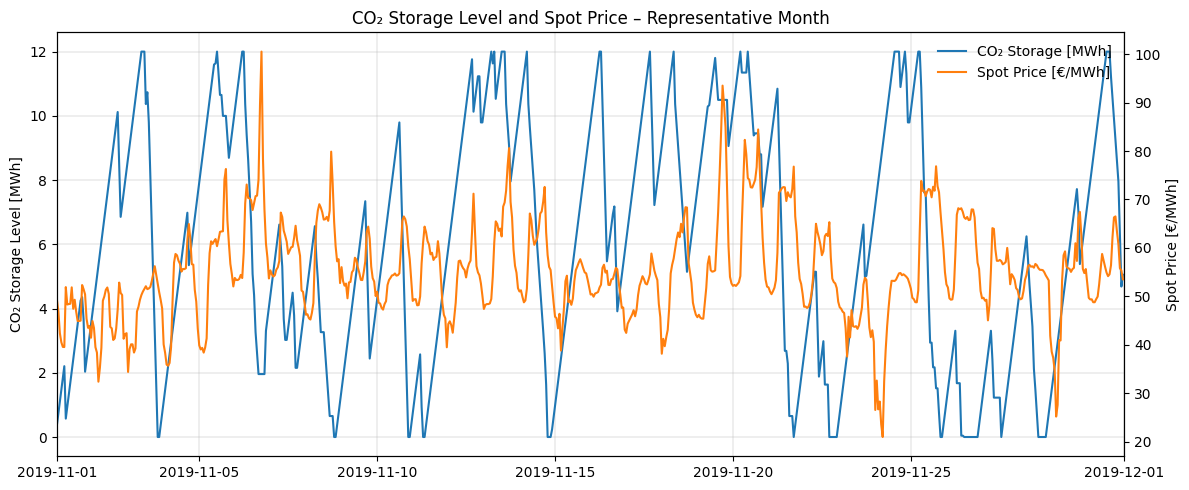

In [4]:
# PLOT SAME FIGURE W/ SECONDARY AXIS
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12, 5))

# --- Storage (primary y-axis) ---
storage_line = ax1.plot(
    month_df.index,
    month_df["BioFixed"],
    color="tab:blue",
    linewidth=1.5,
    label="CO₂ Storage [MWh]"
)
ax1.set_ylabel("CO₂ Storage Level [MWh]")
ax1.grid(True, linewidth=0.3)

# --- Secondary y-axis for Spot Price ---
ax2 = ax1.twinx()
price_line = ax2.plot(
    month_df.index,
    month_df["SpotPrice"],
    color="tab:orange",
    linewidth=1.5,
    label="Spot Price [€/MWh]"
)
ax2.set_ylabel("Spot Price [€/MWh]")

# --- Combined legend ---
lines = storage_line + price_line
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", frameon=False)

# --- X-axis formatting ---
ax1.set_xlim(pd.Timestamp("2019-11-01"), pd.Timestamp("2019-12-01"))
ax1.set_xticks([
    pd.Timestamp("2019-11-01"),
    pd.Timestamp("2019-11-05"),
    pd.Timestamp("2019-11-10"),
    pd.Timestamp("2019-11-15"),
    pd.Timestamp("2019-11-20"),
    pd.Timestamp("2019-11-25"),
    pd.Timestamp("2019-12-01")
])

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# --- Title and layout ---
plt.title("CO₂ Storage Level and Spot Price – Representative Month")
plt.tight_layout()
plt.show()

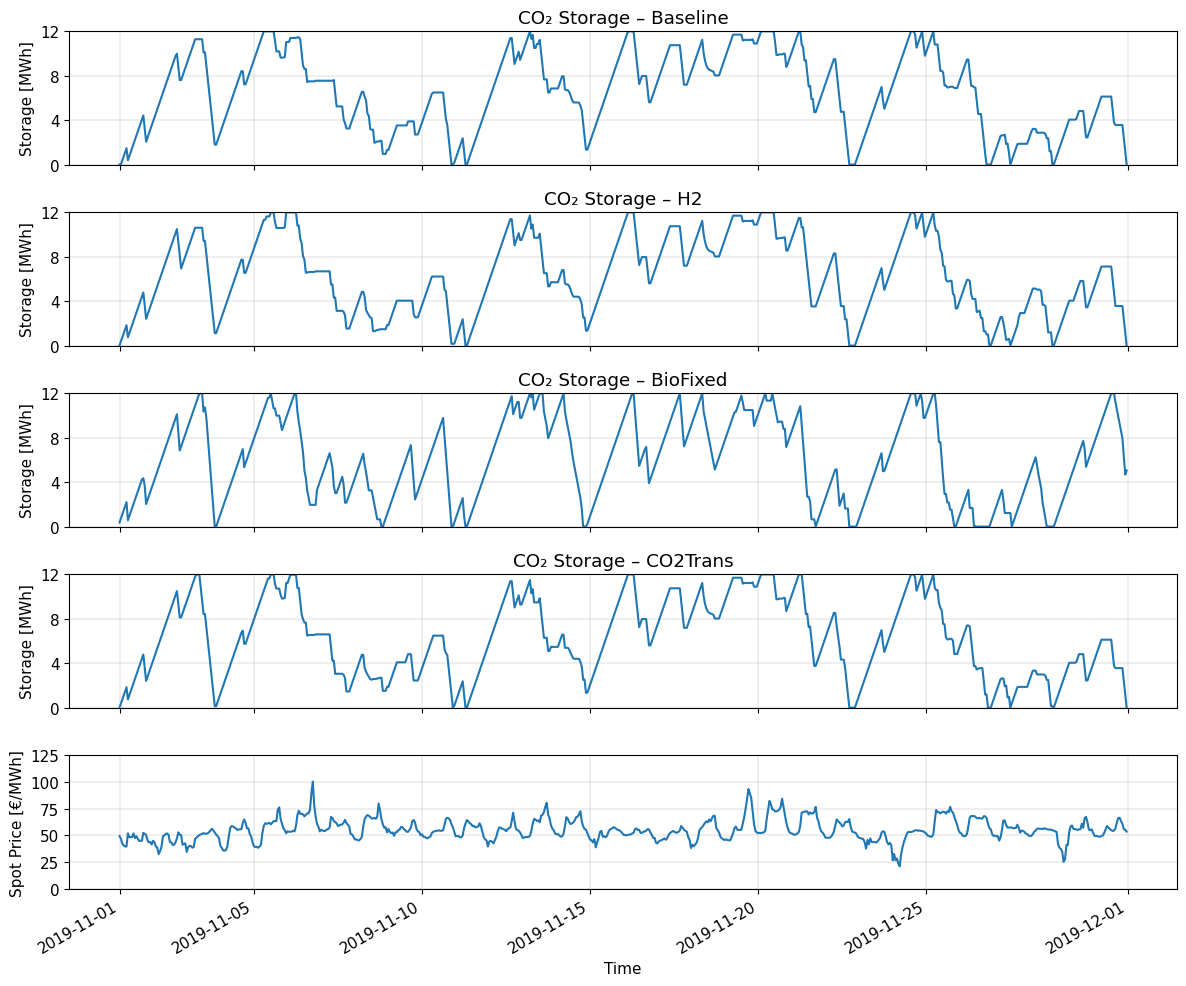

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

scenarios = ["Baseline", "H2",  "BioFixed", "CO2Trans"]

# ---- Plot style ----
plt.rcParams.update({"figure.figsize": (12, 10), "font.size": 11})

# +1 for the bottom Spot Price subplot
fig, axes = plt.subplots(len(scenarios) + 1, 1, sharex=True)

# ---- Storage subplots (one per scenario) ----
for i, sc in enumerate(scenarios):
    ax = axes[i]
    ax.plot(month_df.index, month_df[sc], linewidth=1.5)
    ax.set_ylabel("Storage [MWh]")
    ax.set_title(f"CO₂ Storage – {sc}")
    ax.grid(True, linewidth=0.3)

    # Apply uniform y-limits for storage
    ax.set_ylim(0, 12)
    ax.set_yticks([0, 4, 8, 12])

# ---- Bottom subplot — Spot Price (shared x) ----
ax_price = axes[-1]
ax_price.plot(month_df.index, month_df["SpotPrice"], linewidth=1.5)
ax_price.set_ylabel("Spot Price [€/MWh]")
ax_price.set_xlabel("Time")
ax_price.grid(True, linewidth=0.3)
# Apply uniform y-limits for storage
ax_price.set_ylim(0, 120)
ax_price.set_yticks([0, 25, 50, 75, 100, 125])

# ---- X-axis ticks & formatting on bottom only ----
ax_price.set_xticks([
    pd.Timestamp("2019-11-01"),
    pd.Timestamp("2019-11-05"),
    pd.Timestamp("2019-11-10"),
    pd.Timestamp("2019-11-15"),
    pd.Timestamp("2019-11-20"),
    pd.Timestamp("2019-11-25"),
    pd.Timestamp("2019-12-01"),
])

ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax_price.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
plt.show()


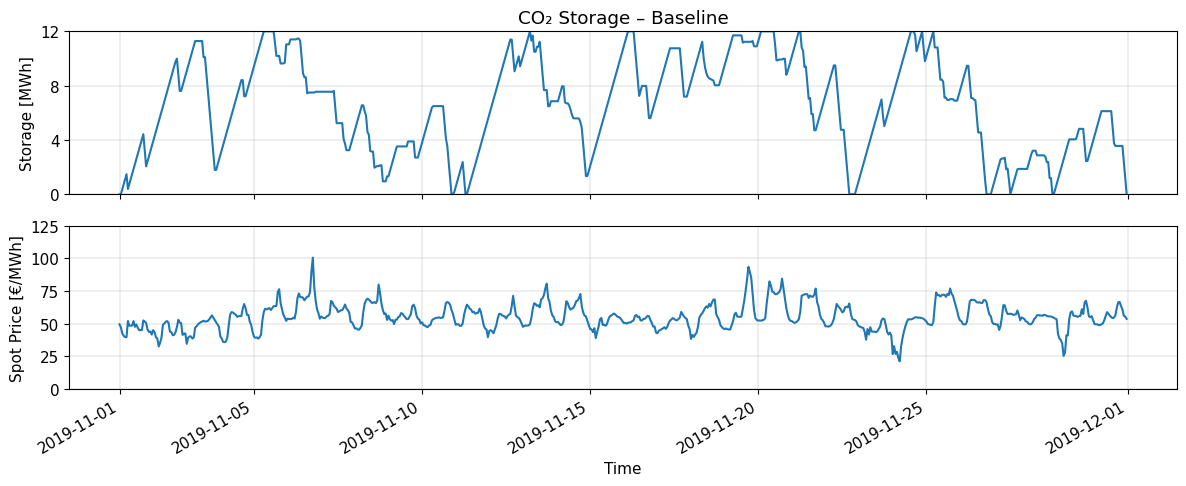

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

scenarios = ["Baseline"]

# ---- Plot style ----
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})

# +1 for the bottom Spot Price subplot
fig, axes = plt.subplots(len(scenarios) + 1, 1, sharex=True)

# ---- Storage subplots (one per scenario) ----
for i, sc in enumerate(scenarios):
    ax = axes[i]
    ax.plot(month_df.index, month_df[sc], linewidth=1.5)
    ax.set_ylabel("Storage [MWh]")
    ax.set_title(f"CO₂ Storage – {sc}")
    ax.grid(True, linewidth=0.3)

    # Apply uniform y-limits for storage
    ax.set_ylim(0, 12)
    ax.set_yticks([0, 4, 8, 12])

# ---- Bottom subplot — Spot Price (shared x) ----
ax_price = axes[-1]
ax_price.plot(month_df.index, month_df["SpotPrice"], linewidth=1.5)
ax_price.set_ylabel("Spot Price [€/MWh]")
ax_price.set_xlabel("Time")
ax_price.grid(True, linewidth=0.3)
# Apply uniform y-limits for storage
ax_price.set_ylim(0, 120)
ax_price.set_yticks([0, 25, 50, 75, 100, 125])

# ---- X-axis ticks & formatting on bottom only ----
ax_price.set_xticks([
    pd.Timestamp("2019-11-01"),
    pd.Timestamp("2019-11-05"),
    pd.Timestamp("2019-11-10"),
    pd.Timestamp("2019-11-15"),
    pd.Timestamp("2019-11-20"),
    pd.Timestamp("2019-11-25"),
    pd.Timestamp("2019-12-01"),
])

ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax_price.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
plt.show()


<Axes: xlabel='datetime'>

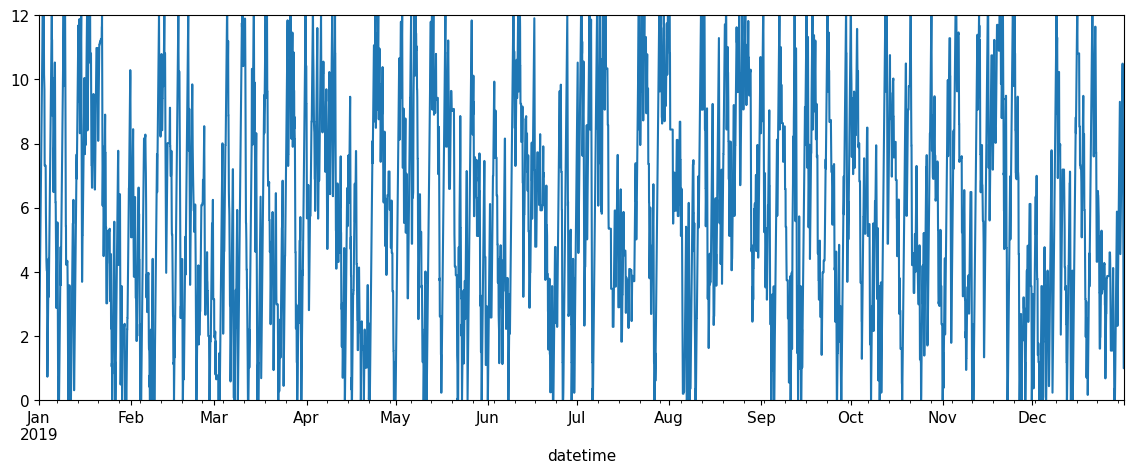

In [8]:
df['Baseline'].plot(ylim=(0,12), figsize=(14,5))

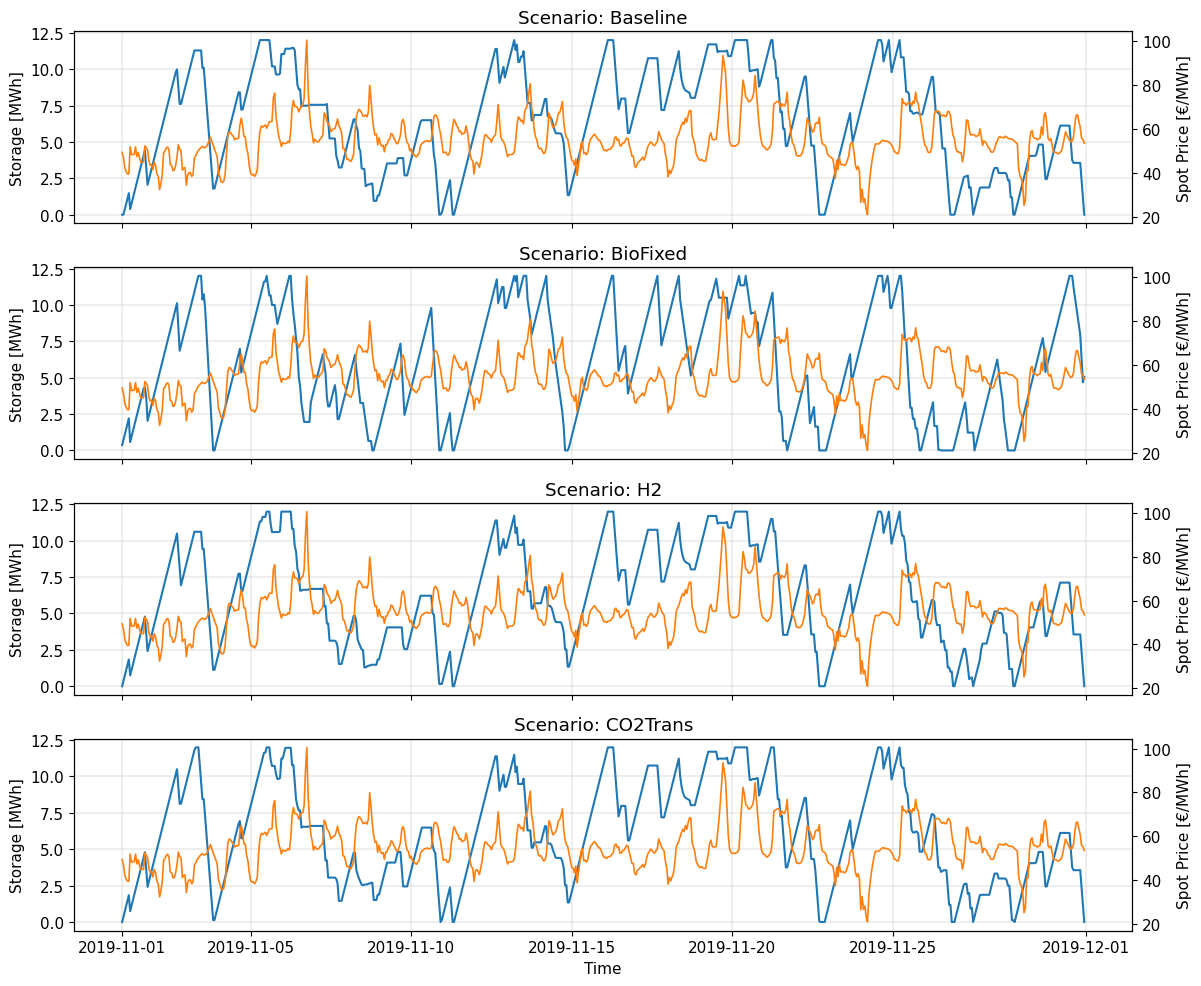

In [7]:
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt

scenarios = ["Baseline", "BioFixed", "H2", "CO2Trans"]

# ---- Create figure ----
plt.rcParams.update({"figure.figsize": (12, 10), "font.size": 11})
fig, axes = plt.subplots(len(scenarios), 1, sharex=True)

for i, sc in enumerate(scenarios):
    ax1 = axes[i]

    # Storage
    ax1.plot(month_df.index, month_df[sc], linewidth=1.5, color="tab:blue", label="Storage")
    ax1.set_ylabel("Storage [MWh]")
    ax1.grid(True, linewidth=0.3)

    # Secondary axis for price
    ax2 = ax1.twinx()
    ax2.plot(month_df.index, month_df["SpotPrice"], linewidth=1.2, color="tab:orange", label="Spot Price")
    ax2.set_ylabel("Spot Price [€/MWh]")

    # Title for each scenario
    ax1.set_title(f"Scenario: {sc}")

# ---- X-axis ticks applied to bottom axis only ----
axes[-1].set_xticks([
    pd.Timestamp("2019-11-01"),
    pd.Timestamp("2019-11-05"),
    pd.Timestamp("2019-11-10"),
    pd.Timestamp("2019-11-15"),
    pd.Timestamp("2019-11-20"),
    pd.Timestamp("2019-11-25"),
    pd.Timestamp("2019-12-01")
])

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()


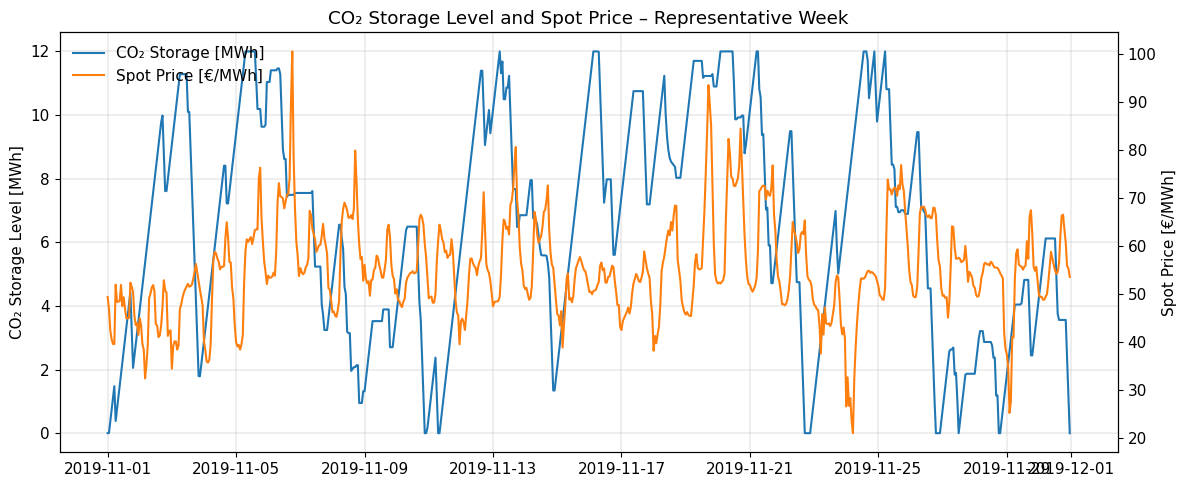

In [9]:
# PLOT SAME FIGURE W/ SECONDARY AXIS 
fig, ax1 = plt.subplots(figsize=(12, 5)) 
# --- Storage (primary y-axis) --- 
storage_line = ax1.plot( month_df.index, month_df["Baseline"], color="tab:blue", linewidth=1.5, label="CO₂ Storage [MWh]" ) 
ax1.set_ylabel("CO₂ Storage Level [MWh]") 
ax1.grid(True, linewidth=0.3) 
# --- Secondary y-axis for Spot Price --- 
ax2 = ax1.twinx() 
price_line = ax2.plot( month_df.index, month_df["SpotPrice"], color="tab:orange", linewidth=1.5, label="Spot Price [€/MWh]" ) 
ax2.set_ylabel("Spot Price [€/MWh]") 
# --- Combined legend --- 
lines = storage_line + price_line 
labels = [l.get_label() for l in lines] 
ax1.legend(lines, labels, loc="upper left", frameon=False) 
# --- Title and layout --- 
plt.title("CO₂ Storage Level and Spot Price – Representative Week") 
plt.tight_layout() 
plt.show()